# Description - To run within SCC
# Creates results using Dense Model
# Currently, the file is created targeting the model saved in the path below
# restricted/projectnb/movelab/bcha/IMUforKnee/trainedModel/Optuna_AutoSearch/

In [1]:
import torch
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import os
from os.path import join
from pickle import load
import pandas as pd
from natsort import natsorted
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# Add the path to access helper modules (Windows path)
import sys
sys.path.append(r'R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\sensorwise')

# Import custom libraries
from dir_CBD import *
from plot_CBD import *
from scaler_CBD import *


In [2]:
motherDir = 'DenseModel'
######### Configuration Section ########
exp_name = 'date_optuna_AutoSearch'  # Experiment name or today's date
modelVersion = 'Optuna_AutoSearch'
nameDataset = 'IWALQQ_1st_correction'  # Updated to match training script
dataType = 'angle'  # Updated to match training script (was 'moBWHT')

# Model location - Updated to match training script output structure
SaveDir = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Training_results\Optuna_AutoSearch\models\final_models"
MODEL_DIR = SaveDir

# Data location - Updated to match training script data path
dataDir = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\Data\allnew_20220325_raw_byDeepak_csv\INC_ByStep\INC_ByZero\Included_checked\SAVE_dataSet"
DATA_DIR = join(dataDir, nameDataset)

# Fixed values
SEQ_LEN = 101
NUM_FEATURES = 42

# AI training settings
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
# Angle prediction model
for numFold in range(0, 5):
   # Load model
   dir_savedTrainedModel = join(MODEL_DIR, f"{dataType}_fold_{numFold}_optuna_best.pt")
   my_model = torch.jit.load(dir_savedTrainedModel, map_location='cpu')
   my_model.eval()
   # Load data
   load_test = np.load(join(DATA_DIR, f"{numFold}_fold_final_test.npz"))
   load_scaler4Y = load(
       open(join(DATA_DIR, f"{numFold}_fold_scaler4Y_{dataType}.pkl"), 'rb')
   )
   # Iterate through individual data for each fold
   for dataIndex in range(load_test['final_X_test'].shape[0]):
       # Prepare input and ground truth data
       X_test = np.squeeze(load_test['final_X_test'][dataIndex])
       X_test = X_test[None, :]  # Add batch dimension
       Y_true = load_test[f'final_Y_{dataType}_test'][dataIndex]

       # Inference
       Y_pred = my_model(
           torch.from_numpy(X_test).type(torch.FloatTensor))
       Y_pred = Y_pred.cpu().detach().numpy()
       Y_pred = np.reshape(Y_pred, [3, -1])
       Y_pred = np.transpose(Y_pred)

       # Reshape Y_true the same way as Y_pred (convert 303-length flat array to 101x3 matrix)
       Y_true = np.reshape(Y_true, [3, -1])
       Y_true = np.transpose(Y_true)

       # Rescale data back to original size
       Y_true_pick_afterscaler = (Y_true - load_scaler4Y.min_) / load_scaler4Y.scale_
       Y_pred_pick_afterscaler = (Y_pred - load_scaler4Y.min_) / load_scaler4Y.scale_

       df_true = pd.DataFrame(Y_true_pick_afterscaler, columns=['X_True','Y_True','Z_True'])
       df_pred = pd.DataFrame(Y_pred_pick_afterscaler, columns=['X_Pred','Y_Pred','Z_Pred'])
       df_save = pd.concat([df_true, df_pred], axis=1)
       dfSaveDir = join(motherDir,modelVersion,nameDataset,dataType,f'{numFold}_fold')
       ensure_dir(dfSaveDir)
       df_save.to_excel(join(dfSaveDir,f'{dataIndex}.xlsx'))
   #     break  # For test data loop break
   # break  # For fold loop break


In [4]:
# import 필요한 라이브러리
import os
from os.path import join
from natsort import natsorted
from pathlib import Path
import shutil
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import plot_CBD

In [5]:
# Main folder name to contain the results
targetDir = join(motherDir,modelVersion,nameDataset,dataType)
for axe in ["X","Y","Z"]:
    print("Axe : ", axe)
    globals()[f"true_{axe}"] = np.array([])
    globals()[f"pred_{axe}"] = np.array([])
    for fold in ["0_fold","1_fold","2_fold","3_fold","4_fold",]:
        print(f"now fold : ", fold)
        list_results = natsorted([_ for _ in os.listdir(join(targetDir,fold)) if _.endswith(".xlsx")])
        for result in list_results:
            singleResult = pd.read_excel(join(targetDir,fold,result))
            true = np.expand_dims(singleResult[f"{axe}_True"].to_numpy(), axis=0)
            pred = np.expand_dims(singleResult[f"{axe}_Pred"].to_numpy(), axis=0)
            
            # Better debug: Check the actual values
            if axe == "Y" and result == "0.xlsx":
                print(f"File: {fold}/{result}")
                print(f"Y_Pred from Excel: {singleResult['Y_Pred'].iloc[:5].values}")
                print(f"pred array: {pred[0, :5]}")
                print(f"pred has NaN: {np.isnan(pred).any()}")
                print(f"Excel Y_Pred has NaN: {singleResult['Y_Pred'].isna().any()}")
                break
            
            if len(globals()[f"true_{axe}"]) ==0:
                globals()[f"true_{axe}"] = true
                globals()[f"pred_{axe}"] = pred
            else:
                globals()[f"true_{axe}"] = np.concatenate((globals()[f"true_{axe}"], true),0)
                globals()[f"pred_{axe}"] = np.concatenate((globals()[f"pred_{axe}"], pred),0)

Axe :  X
now fold :  0_fold
now fold :  1_fold
now fold :  2_fold
now fold :  3_fold
now fold :  4_fold
Axe :  Y
now fold :  0_fold
File: 0_fold/0.xlsx
Y_Pred from Excel: [-2.50379529 -2.57833096 -2.66130853 -2.50573699 -2.74519729]
pred array: [-2.50379529 -2.57833096 -2.66130853 -2.50573699 -2.74519729]
pred has NaN: False
Excel Y_Pred has NaN: False
now fold :  1_fold
File: 1_fold/0.xlsx
Y_Pred from Excel: [-6.30017908 -6.24276328 -5.98280585 -5.7766981  -5.86199675]
pred array: [-6.30017908 -6.24276328 -5.98280585 -5.7766981  -5.86199675]
pred has NaN: False
Excel Y_Pred has NaN: False
now fold :  2_fold
File: 2_fold/0.xlsx
Y_Pred from Excel: [-3.2777663  -3.36918326 -3.12879104 -3.03837971 -2.76339653]
pred array: [-3.2777663  -3.36918326 -3.12879104 -3.03837971 -2.76339653]
pred has NaN: False
Excel Y_Pred has NaN: False
now fold :  3_fold
File: 3_fold/0.xlsx
Y_Pred from Excel: [-1.68316646 -1.53446043 -1.71213402 -1.59609827 -1.65593068]
pred array: [-1.68316646 -1.53446043 -1.7

In [6]:
def makeDataframe(file_Num):
    return pd.DataFrame(data=file_Num.transpose(),index = [idx for idx in range(len(file_Num[0]))],columns=[idx for idx in range(len(file_Num))])

In [7]:
# Rebuild arrays from the fixed Excel files
targetDir = join(motherDir,modelVersion,nameDataset,dataType)

true_X = np.array([])
pred_X = np.array([])
true_Y = np.array([])
pred_Y = np.array([])
true_Z = np.array([])
pred_Z = np.array([])

for fold in ["0_fold","1_fold","2_fold","3_fold","4_fold"]:
    list_results = natsorted([_ for _ in os.listdir(join(targetDir,fold)) if _.endswith(".xlsx")])
    for result in list_results:
        df = pd.read_excel(join(targetDir,fold,result))
        
        for axe in ["X","Y","Z"]:
            true_data = np.expand_dims(df[f"{axe}_True"].to_numpy(), axis=0)
            pred_data = np.expand_dims(df[f"{axe}_Pred"].to_numpy(), axis=0)
            
            if len(globals()[f"true_{axe}"]) == 0:
                globals()[f"true_{axe}"] = true_data
                globals()[f"pred_{axe}"] = pred_data
            else:
                globals()[f"true_{axe}"] = np.concatenate((globals()[f"true_{axe}"], true_data), 0)
                globals()[f"pred_{axe}"] = np.concatenate((globals()[f"pred_{axe}"], pred_data), 0)

print("Arrays rebuilt. Now run your Excel writer code.")

Arrays rebuilt. Now run your Excel writer code.


In [8]:
# Install xlsxwriter if not available
try:
    import xlsxwriter
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xlsxwriter"])
    import xlsxwriter
totalDir = join(motherDir,modelVersion,nameDataset,dataType)
writer = pd.ExcelWriter(join(totalDir,'TruePredDiff.xlsx'), engine='xlsxwriter')
for axe in ["X","Y","Z"]:
    for sess in ["true","pred"]:
        dataName = f"{sess}_{axe}"
        df = makeDataframe(globals()[dataName])
        df.to_excel(writer,sheet_name=str(dataName),index=False)
    df_diff = makeDataframe(abs(globals()[f"true_{axe}"]-globals()[f"pred_{axe}"]))
    df_diff.to_excel(writer,sheet_name=str(f"diff_{axe}"),index=False)
writer.close()  # Changed from save() to close()

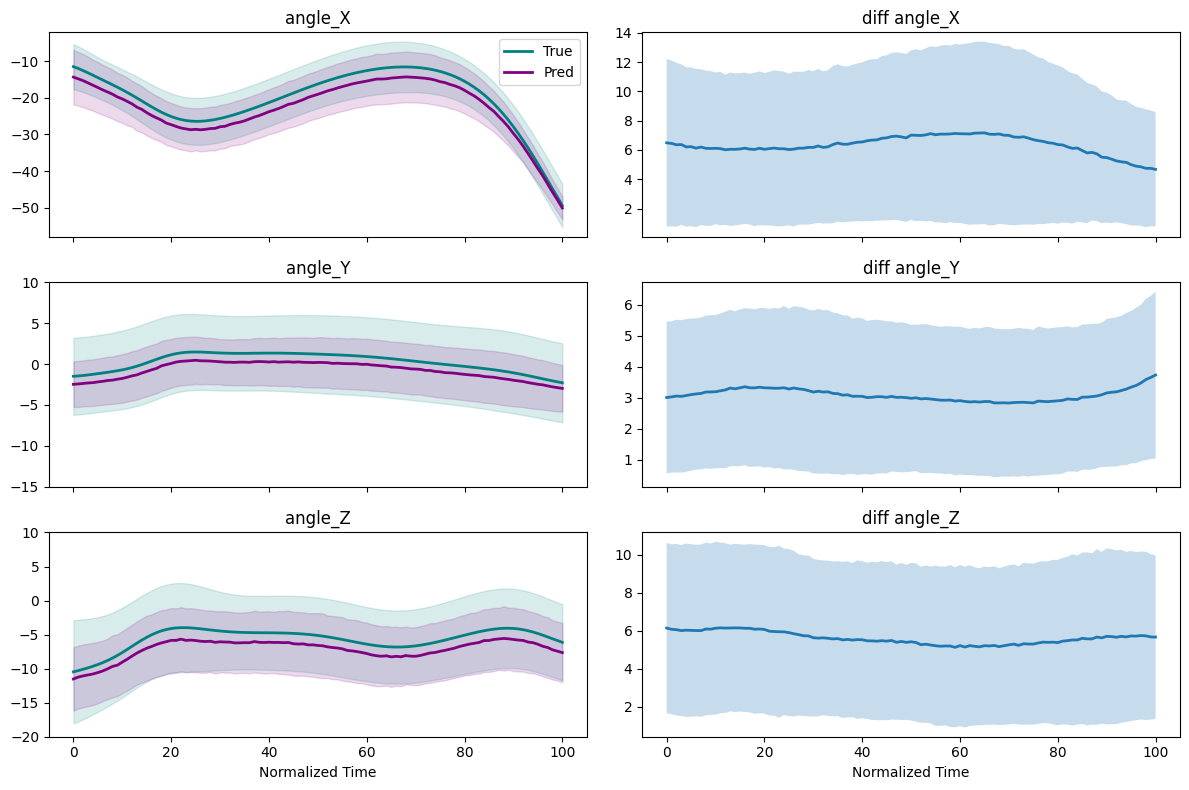

In [9]:
# === 3-row × 2-col summary:  True vs Pred  |  abs-diff ===
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np, matplotlib.pyplot as plt
pp  = PdfPages(join(targetDir, f"WHOLE_Total_result_{dataType}.pdf"))
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
time = np.linspace(0, 100, 101)
angle_labels = ['X', 'Y', 'Z']
for i, (T, P) in enumerate(zip([true_X, true_Y, true_Z],
                              [pred_X, pred_Y, pred_Z])):
   # --- if the matrices are still concatenated (n, 303) take the right slice
   if T.shape[1] == 303:
       sl = slice(i * 101, (i + 1) * 101)
       T, P = T[:, sl], P[:, sl]
   mT, sT = T.mean(0), T.std(0)
   mP, sP = P.mean(0), P.std(0)
   # -------- left column: True vs Pred --------
   ax = axes[i, 0]
   ax.plot(time, mT, lw=2, color='teal',   label='True')
   ax.plot(time, mP, lw=2, color='purple', label='Pred')
   ax.fill_between(time, mT - sT, mT + sT, alpha=0.15, color='teal')
   ax.fill_between(time, mP - sP, mP + sP, alpha=0.15, color='purple')
   ax.set_title(f'angle_{angle_labels[i]}')
   if i == 0:
       ax.legend()
   
   # Set custom y-axis limits for Y and Z to zoom out
   if i == 1:  # Y axis
       ax.set_ylim(-15, 10)
   elif i == 2:  # Z axis
       ax.set_ylim(-20, 10)
   
   # -------- right column: |True – Pred| --------
   diff      = np.abs(T - P)
   mD, sD    = diff.mean(0), diff.std(0)
   axd       = axes[i, 1]
   axd.plot(time, mD, lw=2)
   axd.fill_between(time, mD - sD, mD + sD, alpha=0.25)
   axd.set_title(f'diff angle_{angle_labels[i]}')

axes[-1, 0].set_xlabel('Normalized Time')
axes[-1, 1].set_xlabel('Normalized Time')
plt.tight_layout()
pp.savefig(fig)
pp.close()
plt.show()


In [10]:
# Calculate correlation coefficient and relative RMSE for each axis (FIXED - using overall population range)
import numpy as np
import pandas as pd

results = {}
axis_names = ['X', 'Y', 'Z']

# Use the specific file path
excel_file_path = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\Optuna_AutoSearch\IWALQQ_1st_correction\angle\TruePredDiff.xlsx"

# First pass: Calculate overall population ranges for each axis
overall_ranges = {}
for axis in axis_names:
    true_data = pd.read_excel(excel_file_path, sheet_name=f'true_{axis}', index_col=0)
    
    # Calculate overall population range (min/max across ALL trials)
    overall_min = np.nanmin(true_data.values)
    overall_max = np.nanmax(true_data.values)
    overall_ranges[axis] = overall_max - overall_min
    
    print(f"Axis {axis} - Overall population range: {overall_ranges[axis]:.2f}° (from {overall_min:.2f}° to {overall_max:.2f}°)")

print("\n" + "="*70)

# Second pass: Calculate metrics using overall population ranges
for axis in axis_names:
    # Read the true and predicted data sheets
    true_data = pd.read_excel(excel_file_path, sheet_name=f'true_{axis}', index_col=0)
    pred_data = pd.read_excel(excel_file_path, sheet_name=f'pred_{axis}', index_col=0)
    
    # Calculate correlation for each trial (each column)
    correlations = []
    rel_rmses = []
    
    for trial_col in true_data.columns:  # For each trial (column)
        true_trial = true_data[trial_col].values    # 101 time points for this trial
        pred_trial = pred_data[trial_col].values    # 101 time points for this trial
        
        # Skip if there are NaN values
        if np.isnan(true_trial).any() or np.isnan(pred_trial).any():
            continue
            
        # Correlation for this trial
        trial_corr = np.corrcoef(true_trial, pred_trial)[0, 1]
        correlations.append(trial_corr)
        
        # FIXED: Relative RMSE using overall population range (not individual trial range)
        rmse = np.sqrt(np.mean((pred_trial - true_trial) ** 2))
        rel_rmse = 100 * rmse / overall_ranges[axis]  # Use overall range, not individual trial range
        rel_rmses.append(rel_rmse)
    
    # Average across all trials
    results[f'{axis}_correlation_mean'] = np.mean(correlations)
    results[f'{axis}_correlation_std'] = np.std(correlations)
    results[f'{axis}_rel_rmse_mean'] = np.mean(rel_rmses)
    results[f'{axis}_rel_rmse_std'] = np.std(rel_rmses)

# Print results
print("Results Summary (FIXED - Overall Population Range-based Relative RMSE):")
print("-" * 70)
print(f"{'Axis':<4} {'Corr Mean':<10} {'Corr Std':<10} {'RMSE Mean (%)':<12} {'RMSE Std (%)':<12}")
print("-" * 70)
for axis in axis_names:
    corr_mean = results[f'{axis}_correlation_mean']
    corr_std = results[f'{axis}_correlation_std']
    rmse_mean = results[f'{axis}_rel_rmse_mean']
    rmse_std = results[f'{axis}_rel_rmse_std']
    print(f"{axis:<4} {corr_mean:<10.3f} {corr_std:<10.3f} {rmse_mean:<12.2f} {rmse_std:<12.2f}")

print("\n" + "="*70)
print("Key differences from original:")
print("- Using overall population range for normalization")
print("- Should now match your visual assessment better")
print("- More stable and interpretable relative RMSE values")

Axis X - Overall population range: 75.98° (from -67.41° to 8.56°)
Axis Y - Overall population range: 27.80° (from -13.18° to 14.61°)
Axis Z - Overall population range: 55.54° (from -41.26° to 14.28°)

Results Summary (FIXED - Overall Population Range-based Relative RMSE):
----------------------------------------------------------------------
Axis Corr Mean  Corr Std   RMSE Mean (%) RMSE Std (%)
----------------------------------------------------------------------
X    0.958      0.046      9.00         6.31        
Y    0.640      0.260      11.98        7.67        
Z    0.553      0.298      10.94        6.54        

Key differences from original:
- Using overall population range for normalization
- Should now match your visual assessment better
- More stable and interpretable relative RMSE values


In [11]:
import numpy as np
import pandas as pd

def compare_prediction_spread(excel_file_path):
    """
    Compare the spread (variability) of predictions vs true values
    This directly answers: "Is the spread of predictions similar to the spread of true values?"
    """
    
    axis_names = ['X', 'Y', 'Z']
    
    print("PREDICTION SPREAD ANALYSIS")
    print("=" * 60)
    print(f"{'Axis':<4} {'True Std':<10} {'Pred Std':<10} {'Ratio':<8} {'Status':<20}")
    print("-" * 60)
    
    for axis in axis_names:
        # Read data
        true_data = pd.read_excel(excel_file_path, sheet_name=f'true_{axis}', index_col=0)
        pred_data = pd.read_excel(excel_file_path, sheet_name=f'pred_{axis}', index_col=0)
        
        # Convert to numpy arrays
        T = true_data.values  # (trials, timepoints)
        P = pred_data.values  # (trials, timepoints)
        
        # Calculate standard deviation across trials for each timepoint
        # This is exactly what creates the shaded regions in your plots
        true_std_per_timepoint = T.std(axis=0)  # std across trials at each timepoint
        pred_std_per_timepoint = P.std(axis=0)  # std across trials at each timepoint
        
        # Average standard deviation across all timepoints
        avg_true_std = np.mean(true_std_per_timepoint)
        avg_pred_std = np.mean(pred_std_per_timepoint)
        
        # Ratio: how much smaller/larger is prediction spread vs true spread
        spread_ratio = avg_pred_std / avg_true_std
        
        # Determine status
        if spread_ratio < 0.8:
            status = "OVERCONFIDENT"
        elif spread_ratio > 1.2:
            status = "UNDERCONFIDENT" 
        else:
            status = "WELL CALIBRATED"
        
        print(f"{axis:<4} {avg_true_std:<10.2f} {avg_pred_std:<10.2f} {spread_ratio:<8.3f} {status:<20}")
    
    print("-" * 60)
    print("\nInterpretation:")
    print("- Ratio < 0.8: OVERCONFIDENT (predictions too consistent)")
    print("- Ratio > 1.2: UNDERCONFIDENT (predictions too variable)")
    print("- Ratio 0.8-1.2: WELL CALIBRATED (appropriate variability)")
    print("\nThis directly measures what you see in the plot:")
    print("- Purple shaded region width vs Teal shaded region width")

# Run the analysis
if __name__ == "__main__":
    excel_file_path = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\Optuna_AutoSearch\IWALQQ_1st_correction\angle\TruePredDiff.xlsx"
    
    compare_prediction_spread(excel_file_path)

PREDICTION SPREAD ANALYSIS
Axis True Std   Pred Std   Ratio    Status              
------------------------------------------------------------
X    8.71       7.90       0.908    WELL CALIBRATED     
Y    1.65       1.19       0.721    OVERCONFIDENT       
Z    2.93       1.81       0.618    OVERCONFIDENT       
------------------------------------------------------------

Interpretation:
- Ratio < 0.8: OVERCONFIDENT (predictions too consistent)
- Ratio > 1.2: UNDERCONFIDENT (predictions too variable)
- Ratio 0.8-1.2: WELL CALIBRATED (appropriate variability)

This directly measures what you see in the plot:
- Purple shaded region width vs Teal shaded region width



=== AXIS X RANGE ANALYSIS ===
Number of trials: 875
Mean range across trials: 40.10°
Std of ranges: 5.54°
Minimum range (smallest trial): 14.92°
Maximum range (largest trial): 56.28°
Range of ranges: 41.36°

First 10 trial ranges:
  Trial 1: 37.07°
  Trial 2: 37.26°
  Trial 3: 37.90°
  Trial 4: 37.81°
  Trial 5: 40.76°
  Trial 6: 40.39°
  Trial 7: 38.33°
  Trial 8: 36.44°
  Trial 9: 37.40°
  Trial 10: 36.44°

Overall population range: 75.98° (from -67.41° to 8.56°)

=== AXIS Y RANGE ANALYSIS ===
Number of trials: 875
Mean range across trials: 6.45°
Std of ranges: 2.33°
Minimum range (smallest trial): 1.49°
Maximum range (largest trial): 15.16°
Range of ranges: 13.67°

First 10 trial ranges:
  Trial 1: 7.78°
  Trial 2: 9.36°
  Trial 3: 8.09°
  Trial 4: 6.93°
  Trial 5: 7.91°
  Trial 6: 7.08°
  Trial 7: 8.19°
  Trial 8: 9.56°
  Trial 9: 11.04°
  Trial 10: 10.65°

Overall population range: 27.80° (from -13.18° to 14.61°)

=== AXIS Z RANGE ANALYSIS ===
Number of trials: 875
Mean range acr

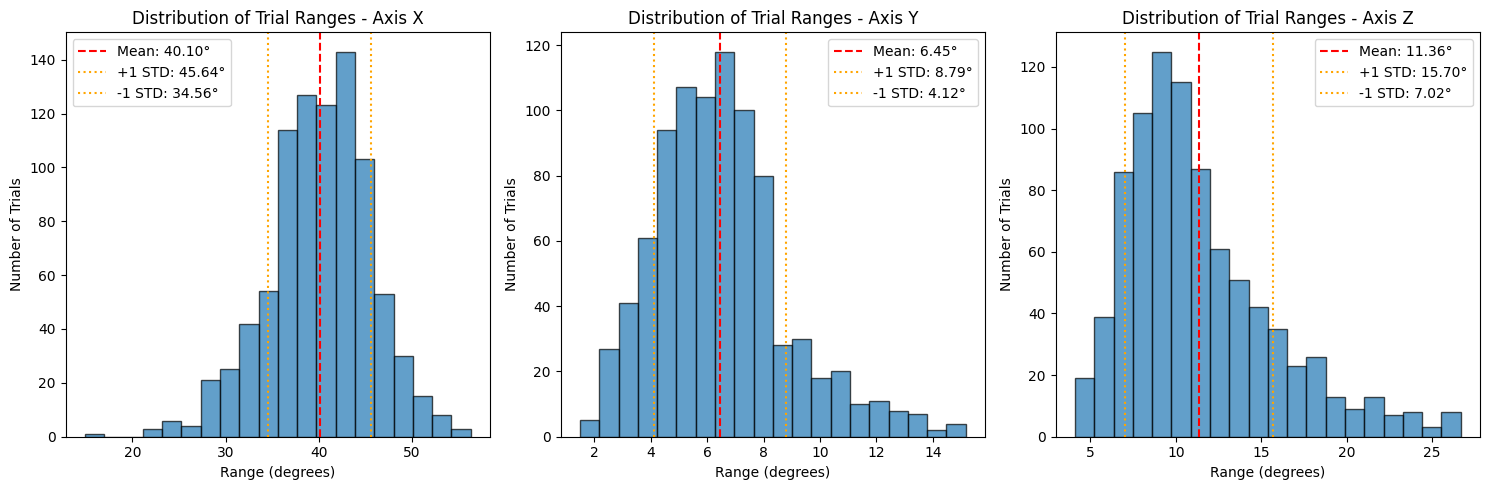


DEMONSTRATION: How different ranges affect relative RMSE
Trial 1 - Range: 5.0°, RMSE: 3.0°, Relative RMSE: 60.0%
Trial 2 - Range: 40.0°, RMSE: 3.0°, Relative RMSE: 7.5%
Average Relative RMSE: 33.8%

Same prediction quality, but VERY different relative RMSE values!
This is why your metrics don't match what you see visually.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Your file path
excel_file_path = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\Optuna_AutoSearch\IWALQQ_1st_correction\angle\TruePredDiff.xlsx"

axis_names = ['X', 'Y', 'Z']
range_analysis = {}

for axis in axis_names:
    # Read the true data
    true_data = pd.read_excel(excel_file_path, sheet_name=f'true_{axis}', index_col=0)
    
    # Calculate range for each trial (each column)
    trial_ranges = []
    trial_mins = []
    trial_maxs = []
    
    for trial_col in true_data.columns:
        true_trial = true_data[trial_col].values
        
        # Skip if there are NaN values
        if np.isnan(true_trial).any():
            continue
            
        trial_min = np.min(true_trial)
        trial_max = np.max(true_trial)
        trial_range = trial_max - trial_min
        
        trial_ranges.append(trial_range)
        trial_mins.append(trial_min)
        trial_maxs.append(trial_max)
    
    # Store results
    range_analysis[axis] = {
        'ranges': trial_ranges,
        'mins': trial_mins,
        'maxs': trial_maxs,
        'mean_range': np.mean(trial_ranges),
        'std_range': np.std(trial_ranges),
        'min_range': np.min(trial_ranges),
        'max_range': np.max(trial_ranges)
    }
    
    print(f"\n=== AXIS {axis} RANGE ANALYSIS ===")
    print(f"Number of trials: {len(trial_ranges)}")
    print(f"Mean range across trials: {np.mean(trial_ranges):.2f}°")
    print(f"Std of ranges: {np.std(trial_ranges):.2f}°")
    print(f"Minimum range (smallest trial): {np.min(trial_ranges):.2f}°")
    print(f"Maximum range (largest trial): {np.max(trial_ranges):.2f}°")
    print(f"Range of ranges: {np.max(trial_ranges) - np.min(trial_ranges):.2f}°")
    
    # Show some individual trial ranges
    print(f"\nFirst 10 trial ranges:")
    for i, r in enumerate(trial_ranges[:10]):
        print(f"  Trial {i+1}: {r:.2f}°")
    
    # Calculate overall population range
    overall_min = np.min(trial_mins)
    overall_max = np.max(trial_maxs)
    overall_range = overall_max - overall_min
    print(f"\nOverall population range: {overall_range:.2f}° (from {overall_min:.2f}° to {overall_max:.2f}°)")

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, axis in enumerate(axis_names):
    ax = axes[i]
    ranges = range_analysis[axis]['ranges']
    
    # Histogram of ranges
    ax.hist(ranges, bins=20, alpha=0.7, edgecolor='black')
    ax.set_title(f'Distribution of Trial Ranges - Axis {axis}')
    ax.set_xlabel('Range (degrees)')
    ax.set_ylabel('Number of Trials')
    
    # Add statistics
    mean_range = range_analysis[axis]['mean_range']
    std_range = range_analysis[axis]['std_range']
    ax.axvline(mean_range, color='red', linestyle='--', 
               label=f'Mean: {mean_range:.2f}°')
    ax.axvline(mean_range + std_range, color='orange', linestyle=':', 
               label=f'+1 STD: {mean_range + std_range:.2f}°')
    ax.axvline(mean_range - std_range, color='orange', linestyle=':', 
               label=f'-1 STD: {mean_range - std_range:.2f}°')
    ax.legend()

plt.tight_layout()
plt.show()

# Demonstrate the RMSE calculation problem
print("\n" + "="*80)
print("DEMONSTRATION: How different ranges affect relative RMSE")
print("="*80)

# Simulate two trials with same 3° RMSE but different ranges
trial1_range = 5.0   # Small range trial
trial2_range = 40.0  # Large range trial
rmse = 3.0          # Same RMSE for both

rel_rmse1 = 100 * rmse / trial1_range
rel_rmse2 = 100 * rmse / trial2_range

print(f"Trial 1 - Range: {trial1_range}°, RMSE: {rmse}°, Relative RMSE: {rel_rmse1:.1f}%")
print(f"Trial 2 - Range: {trial2_range}°, RMSE: {rmse}°, Relative RMSE: {rel_rmse2:.1f}%")
print(f"Average Relative RMSE: {(rel_rmse1 + rel_rmse2)/2:.1f}%")
print(f"\nSame prediction quality, but VERY different relative RMSE values!")
print(f"This is why your metrics don't match what you see visually.")

INDIVIDUAL TRIAL PERFORMANCE ANALYSIS
Axis  Total Trials         r > 0.5         r > 0.6         r > 0.7         r > 0.8         r > 0.9      RMSE < 10%      RMSE < 11%      RMSE < 12%      RMSE < 13%      RMSE < 14% Best r Worst r Best RMSE Worst RMSE
   X           875 874/875 (99.9%) 873/875 (99.8%) 873/875 (99.8%) 864/875 (98.7%) 799/875 (91.3%) 585/875 (66.9%) 618/875 (70.6%) 657/875 (75.1%) 682/875 (77.9%) 709/875 (81.0%)  0.998   0.495     1.26%     36.38%
   Y           875 658/875 (75.2%) 563/875 (64.3%) 452/875 (51.7%) 283/875 (32.3%) 106/875 (12.1%) 452/875 (51.7%) 493/875 (56.3%) 535/875 (61.1%) 575/875 (65.7%) 598/875 (68.3%)  0.990  -0.706     2.09%     49.49%
   Z           875 571/875 (65.3%) 473/875 (54.1%) 335/875 (38.3%) 186/875 (21.3%)   54/875 (6.2%) 487/875 (55.7%) 535/875 (61.1%) 581/875 (66.4%) 615/875 (70.3%) 645/875 (73.7%)  0.974  -0.691     1.76%     41.81%


DETAILED STATISTICS
Axis r mean r std r median RMSE mean RMSE std RMSE median
   X  0.958 0.046    0

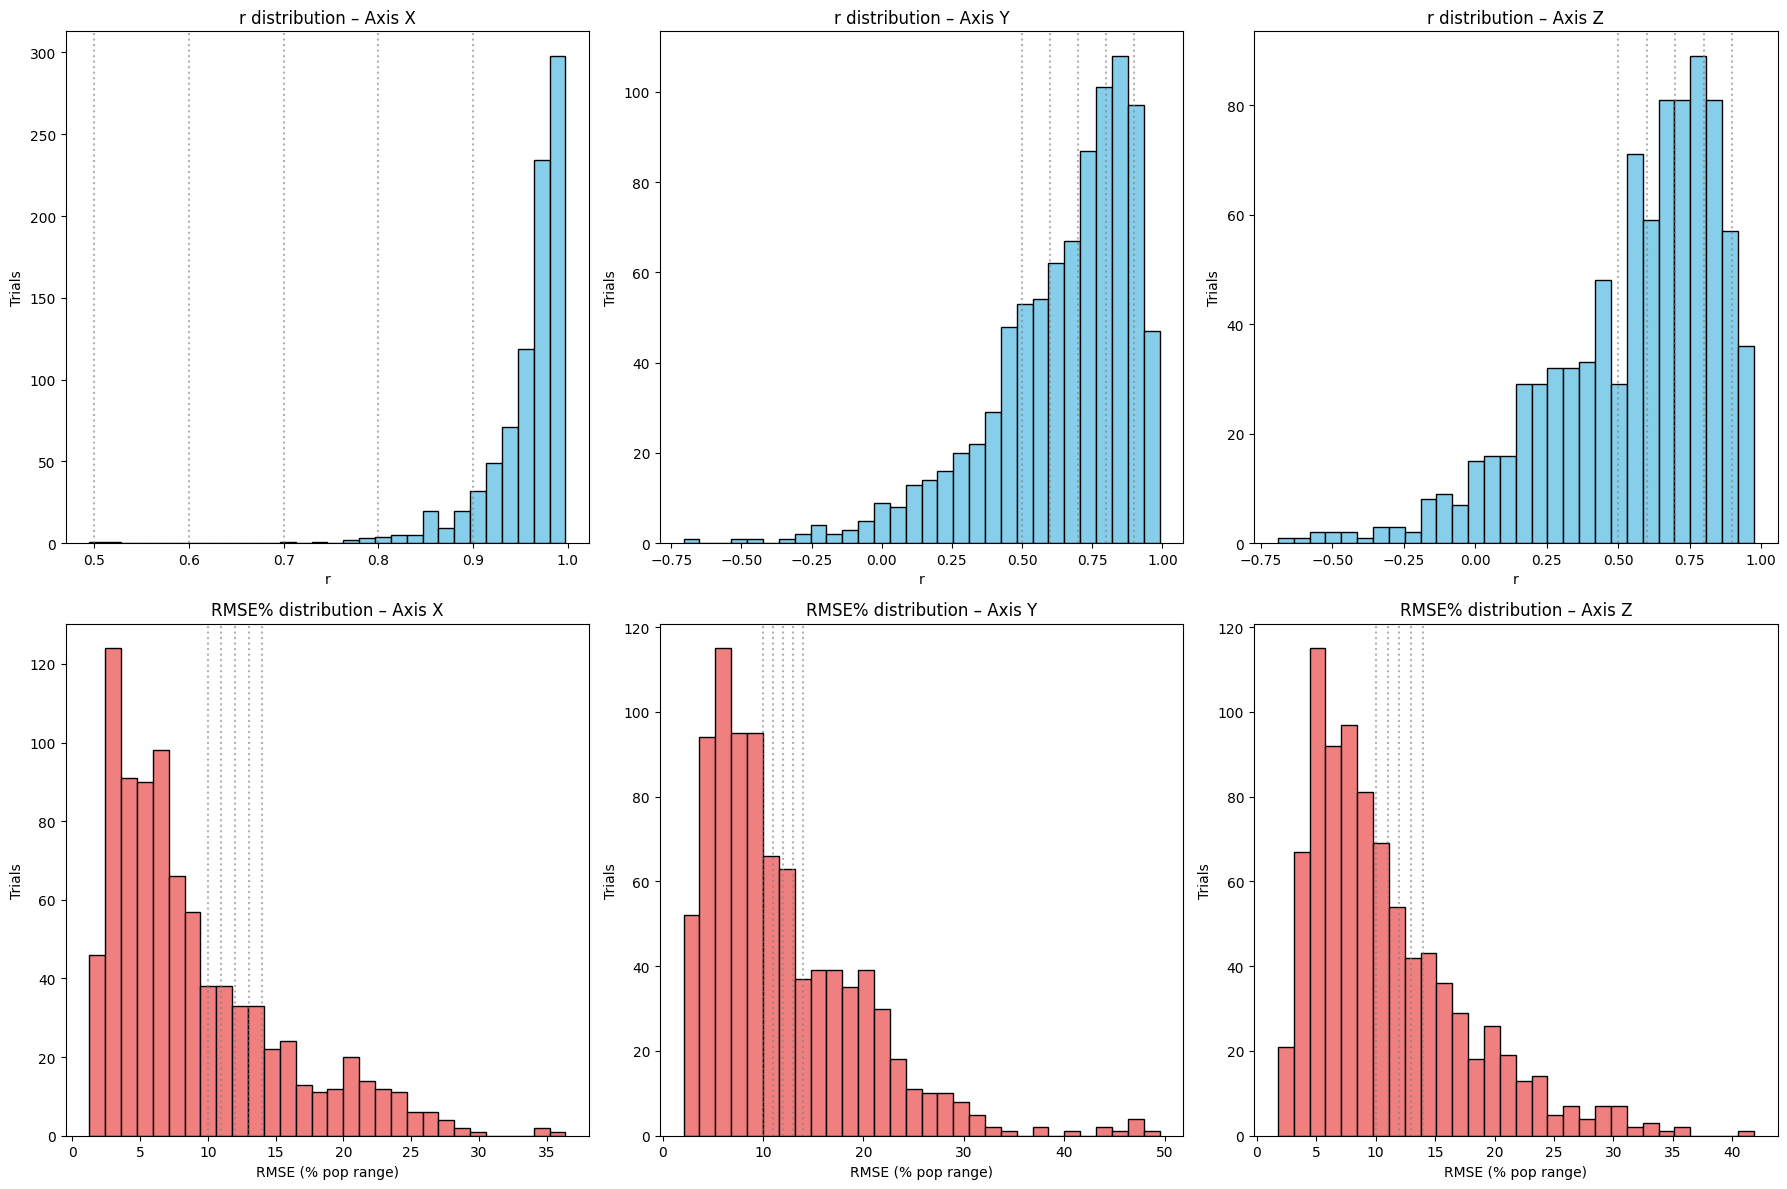


SUMMARY FOR PROFESSOR
  Axis X: 799/875 (91.3%) trials have r > 0.9
  Axis X: 864/875 (98.7%) trials have r > 0.8
  Axis X: 873/875 (99.8%) trials have r > 0.7
  Axis X: 873/875 (99.8%) trials have r > 0.6
  Axis X: 874/875 (99.9%) trials have r > 0.5
  Axis X: 585/875 (66.9%) trials have RMSE < 10%
  Axis X: 618/875 (70.6%) trials have RMSE < 11%
  Axis X: 657/875 (75.1%) trials have RMSE < 12%
  Axis X: 682/875 (77.9%) trials have RMSE < 13%
  Axis X: 709/875 (81.0%) trials have RMSE < 14%
  Axis X: Worst trial r = 0.495, RMSE = 36.4%

  Axis Y: 106/875 (12.1%) trials have r > 0.9
  Axis Y: 283/875 (32.3%) trials have r > 0.8
  Axis Y: 452/875 (51.7%) trials have r > 0.7
  Axis Y: 563/875 (64.3%) trials have r > 0.6
  Axis Y: 658/875 (75.2%) trials have r > 0.5
  Axis Y: 452/875 (51.7%) trials have RMSE < 10%
  Axis Y: 493/875 (56.3%) trials have RMSE < 11%
  Axis Y: 535/875 (61.1%) trials have RMSE < 12%
  Axis Y: 575/875 (65.7%) trials have RMSE < 13%
  Axis Y: 598/875 (68.3%) tri

In [13]:
# =============================================================
# INDIVIDUAL TRIAL PERFORMANCE ANALYSIS
# Reports r > 0.5–0.9  AND  RMSE < 10–14 %
# =============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- SETTINGS ----------
axis_names = ['X', 'Y', 'Z']
excel_file_path = (
    r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee"
    r"\estimation\notsensor\DenseModel\Optuna_AutoSearch"
    r"\IWALQQ_1st_correction\angle\TruePredDiff.xlsx"
)
corr_thresholds = [0.5, 0.6, 0.7, 0.8, 0.9]   # r thresholds
rmse_thresholds = [10, 11, 12, 13, 14]        # RMSE% thresholds
# --------------------------------

# ---------- STEP 1: population ranges ----------
overall_ranges = {}
for axis in axis_names:
    df_true = pd.read_excel(excel_file_path, sheet_name=f'true_{axis}', index_col=0)
    overall_ranges[axis] = np.nanmax(df_true.values) - np.nanmin(df_true.values)

# ---------- STEP 2: per‑trial metrics ----------
trial_results = {ax: {'corr': [], 'rmse_pct': []} for ax in axis_names}

for axis in axis_names:
    true_df = pd.read_excel(excel_file_path, sheet_name=f'true_{axis}', index_col=0)
    pred_df = pd.read_excel(excel_file_path, sheet_name=f'pred_{axis}', index_col=0)
    
    for col in true_df.columns:
        t = true_df[col].values
        p = pred_df[col].values
        if np.isnan(t).any() or np.isnan(p).any():
            continue
        
        r        = np.corrcoef(t, p)[0, 1]
        rmse     = np.sqrt(np.mean((p - t) ** 2))
        rmse_pct = 100 * rmse / overall_ranges[axis]
        
        trial_results[axis]['corr'].append(r)
        trial_results[axis]['rmse_pct'].append(rmse_pct)

# ---------- STEP 3: summary tables ----------
summary_rows  = []
detailed_rows = []

for axis in axis_names:
    corrs = np.array(trial_results[axis]['corr'])
    rmses = np.array(trial_results[axis]['rmse_pct'])
    tot   = len(corrs)
    
    row = {'Axis': axis, 'Total Trials': tot}
    # correlation thresholds
    for thr in corr_thresholds:
        n = np.sum(corrs > thr)
        row[f'r > {thr:.1f}'] = f"{n}/{tot} ({100*n/tot:.1f}%)"
    # RMSE thresholds
    for thr in rmse_thresholds:
        n = np.sum(rmses < thr)
        row[f'RMSE < {thr}%'] = f"{n}/{tot} ({100*n/tot:.1f}%)"
    # extremes
    row['Best r']     = f"{np.max(corrs):.3f}"
    row['Worst r']    = f"{np.min(corrs):.3f}"
    row['Best RMSE']  = f"{np.min(rmses):.2f}%"
    row['Worst RMSE'] = f"{np.max(rmses):.2f}%"
    summary_rows.append(row)
    
    detailed_rows.append({
        'Axis': axis,
        'r mean':   f"{np.mean(corrs):.3f}",
        'r std':    f"{np.std(corrs):.3f}",
        'r median': f"{np.median(corrs):.3f}",
        'RMSE mean':   f"{np.mean(rmses):.2f}%",
        'RMSE std':    f"{np.std(rmses):.2f}%",
        'RMSE median': f"{np.median(rmses):.2f}%"
    })

df_summary  = pd.DataFrame(summary_rows)
df_detailed = pd.DataFrame(detailed_rows)

print("INDIVIDUAL TRIAL PERFORMANCE ANALYSIS")
print("="*130)
print(df_summary.to_string(index=False))

print("\n\nDETAILED STATISTICS")
print("="*60)
print(df_detailed.to_string(index=False))

# ---------- STEP 4: visualisations ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, axis in enumerate(axis_names):
    corrs = trial_results[axis]['corr']
    rmses = trial_results[axis]['rmse_pct']
    
    ax_corr = axes[0, i]
    ax_corr.hist(corrs, bins=30, color='skyblue', edgecolor='black')
    ax_corr.set_title(f'r distribution – Axis {axis}')
    ax_corr.set_xlabel('r'); ax_corr.set_ylabel('Trials')
    for thr in corr_thresholds:
        ax_corr.axvline(thr, color='grey', linestyle=':', alpha=0.6)
    
    ax_rmse = axes[1, i]
    ax_rmse.hist(rmses, bins=30, color='lightcoral', edgecolor='black')
    ax_rmse.set_title(f'RMSE% distribution – Axis {axis}')
    ax_rmse.set_xlabel('RMSE (% pop range)'); ax_rmse.set_ylabel('Trials')
    for thr in rmse_thresholds:
        ax_rmse.axvline(thr, color='grey', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# ---------- STEP 5: concise professor‑style summary ----------
print("\n" + "="*80)
print("SUMMARY FOR PROFESSOR")
print("="*80)
for axis in axis_names:
    corrs = np.array(trial_results[axis]['corr'])
    rmses = np.array(trial_results[axis]['rmse_pct'])
    total = len(corrs)
    
    for thr in corr_thresholds[::-1]:
        n = np.sum(corrs > thr)
        print(f"  Axis {axis}: {n}/{total} ({100*n/total:.1f}%) trials have r > {thr:.1f}")
    for thr in rmse_thresholds:
        n = np.sum(rmses < thr)
        print(f"  Axis {axis}: {n}/{total} ({100*n/total:.1f}%) trials have RMSE < {thr}%")
    print(f"  Axis {axis}: Worst trial r = {np.min(corrs):.3f}, RMSE = {np.max(rmses):.1f}%\n")


In [14]:
excel_file_path = r"R:\KumarLab3\PROJECTS\wesens\Data\Analysis\smith_dl\IMU Deep Learning\IMUforKnee\estimation\notsensor\DenseModel\Optuna_AutoSearch\IWALQQ_1st_correction\angle\TruePredDiff.xlsx"
